# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

## AudioSet

Dataset with 10 numbers pronounced
```
!git clone https://github.com/soerenab/AudioMNIST.git
```



## Task 1(2 points)

Impelment strightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy

In [ ]:
import os
import random
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from IPython.display import Audio
from pathlib import Path
from omegaconf import DictConfig

import torch
import librosa
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from tqdm.notebook import tqdm
from torch.utils.data import Subset, DataLoader
from torchaudio import transforms
from sklearn.manifold import TSNE

import warnings
# warnings.filterwarnings("ignore", module="torchaudio._backend")
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14})

In [60]:
# Настройка устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)

Используемое устройство: cuda


In [61]:
# Клонирование датасета (если еще не сделано)
# !git clone https://github.com/soerenab/AudioMNIST.git

# Загрузка данных
root = 'AudioMNIST/data'

In [62]:
class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000):
        self.root = root
        self.sr = sr
        self.items = self.list_wavs_and_labels(root)
    
    def __len__(self):
        return len(self.items)
    
    def list_wavs_and_labels(self, root: str):
        base = Path(root)
        speakers = sorted([p for p in base.iterdir() if p.is_dir()])
        items = []
        for sp in speakers:
            for wav in sorted(sp.glob("**/*.wav")):
                name = wav.stem.split("_")
                digit = int(name[0])
                speaker_id = sp.name
                items.append((str(wav), digit, speaker_id))
        return items
    
    def load_wav(self, path):
        import librosa
        y, sr = librosa.load(path, sr=None, mono=True)
        wav = torch.from_numpy(y).float().unsqueeze(0)
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)
        return wav
    
    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)
        return wav, label

def collate(batch):
    wavs, labels = zip(*batch)
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)
    labels = torch.tensor(labels, dtype=torch.long)
    return wavs, labels

In [63]:
# Создание датасета и разделение по говорящим
full_ds = AudioMNISTDataset(root=root)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
NUM_TEST_SPEAKERS = 12
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])

def split_indices_by_speaker(dataset, test_speakers):
    train_idxs = []
    test_idxs = []
    for idx, (_, _, spk) in enumerate(dataset.items):
        if spk in test_speakers:
            test_idxs.append(idx)
        else:
            train_idxs.append(idx)
    return train_idxs, test_idxs

train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)
train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)

In [ ]:
class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet1D(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block):
        super(ResNet1D, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(output_size=1)


        # size after avgpool = [32, 512, 1]

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        #x = x.reshape(x.shape[0], -1)
        #x = self.fc(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv1d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm1d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet1D():
    return ResNet1D(block)



class block_resnet2d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block_resnet2d, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, image_channels):
        super(ResNet, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))


    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm2d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet2D(img_channels=3):
    return ResNet(block_resnet2d, image_channels=img_channels)

In [65]:
class Net(nn.Module):

    def __init__(self, img_channels = 1, num_classes = 35):
        super(Net, self).__init__()
        ####################### ENCODER ###################################
        self.resnet_1D = CreateResNet1D()
        self.resnet_2D = CreateResNet2D(img_channels=img_channels)

        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        ####################################################################

    def forward(self, input_spectogram, input_audio):
        """
            resnet2d and resnet1d output is [BS, 512, 1, 1]
            Output:
                - audio_emb, specs_emb used for contrastive loss
                - audio, spectograms used for Evaluation layer
                - output used for semi supervised - cross entropy
        """

        audio = self.resnet_1D(input_audio)
        audio = audio.squeeze()
        spectograms = self.resnet_2D(input_spectogram)
        spectograms = spectograms.squeeze()

        audio_emb = self.output(audio)
        specs_emb = self.output(spectograms)

        return audio_emb, specs_emb, audio, spectograms


class EvaluationHead(nn.Module):
    """
    Linear classifier head
    """
    def __init__(self, num_classes = 35):
        super(EvaluationHead, self).__init__()

        self.evaluation = nn.Sequential(
                    nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x = self.evaluation(x)
        return x

In [66]:
# Классификатор на основе ResNet1D для контролируемого обучения
class SupervisedResNet1D(nn.Module):
    def __init__(self, num_classes=10):
        super(SupervisedResNet1D, self).__init__()
        # Используем энкодер из семинара
        self.encoder = CreateResNet1D()
        self.classifier = nn.Linear(512, num_classes)
    
    def forward(self, x):
        # x имеет форму [batch, time], добавляем dimension для каналов
        if x.dim() == 2:
            x = x.unsqueeze(1)  # [batch, 1, time]
        features = self.encoder(x)
        features = features.squeeze()  # [batch, 512]
        output = self.classifier(features)
        return output

In [67]:
# Функция обучения
def train_supervised(model, train_loader, val_loader, epochs=2, lr=1e-3): # epochs=20
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3)
    
    train_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f'Эпоха {epoch+1}/{epochs}')
        
        for audio, labels in progress_bar:
            audio, labels = audio.to(device), labels.to(device)
            
            # Добавляем размерность канала если нужно
            if audio.dim() == 2:
                audio = audio.unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(audio)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
        
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Валидация
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for audio, labels in val_loader:
                audio, labels = audio.to(device), labels.to(device)
                outputs = model(audio)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = correct / total
        val_accuracies.append(accuracy)
        
        print(f'Эпоха {epoch+1}: Потери = {avg_loss:.4f}, Точность = {accuracy:.4f}')
    
    return train_losses, val_accuracies

In [68]:
# Настройка загрузчиков
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
val_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False, collate_fn=collate)

In [69]:
# Обучение
print("Обучение контролируемой модели...")
supervised_model = SupervisedResNet1D(num_classes=10)
train_losses, val_accuracies = train_supervised(supervised_model, train_loader, val_loader, epochs=2) # epochs=20

Обучение контролируемой модели...


Эпоха 1/2:   0%|          | 0/375 [00:00<?, ?it/s]

Эпоха 1: Потери = 0.3820, Точность = 0.8532


Эпоха 2/2:   0%|          | 0/375 [00:00<?, ?it/s]

Эпоха 2: Потери = 0.1194, Точность = 0.6813


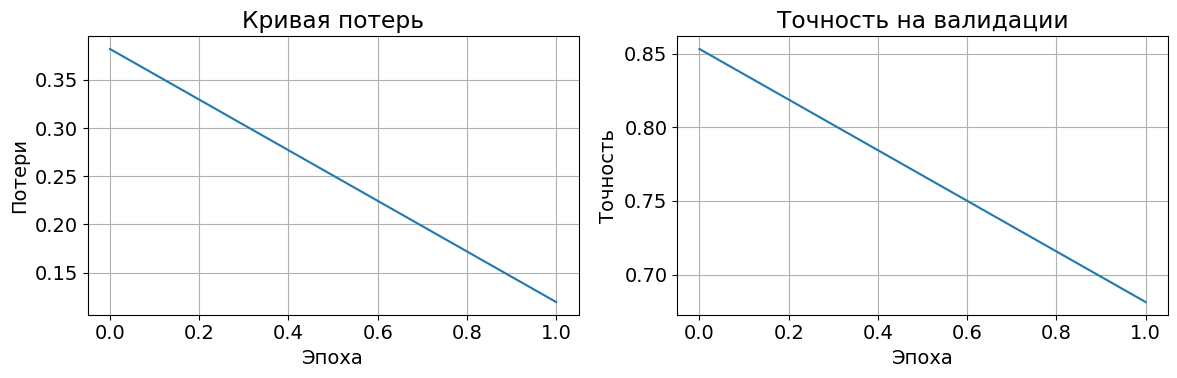


Итоговая точность: 0.6813


In [70]:
# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses)
ax1.set_title('Кривая потерь')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Потери')
ax1.grid(True)
ax2.plot(val_accuracies)
ax2.set_title('Точность на валидации')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Точность')
ax2.grid(True)
plt.tight_layout()
plt.show()

print(f"\nИтоговая точность: {val_accuracies[-1]:.4f}")

## Task 2(2 points)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

In [ ]:
# Задание 2: Contrastive Learning (InfoNCE)

def device_as(t1, t2):
   return t1.to(t2.device)

class ContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
    
    def calc_similarity_batch(self, a, b):
        rep = torch.cat([a, b])
        return F.cosine_similarity(rep.unsqueeze(1), rep.unsqueeze(0), dim=2)
    
    def forward(self, proj_1, proj_2):
        batch_size = proj_1.shape[0]
        z_i = F.normalize(proj_1, p=2, dim=1)
        z_j = F.normalize(proj_2, p=2, dim=1)
        
        similarity_matrix = self.calc_similarity_batch(z_i, z_j)
        
        sim_ij = torch.diag(similarity_matrix, batch_size)
        sim_ji = torch.diag(similarity_matrix, -batch_size)
        
        positives = torch.cat([sim_ij, sim_ji])
        nominator = torch.exp(positives / self.temperature)
        
        mask = (~torch.eye(batch_size*2, batch_size*2).bool()).float()
        mask = device_as(mask, similarity_matrix)
        
        denominator = mask * torch.exp(similarity_matrix / self.temperature)
        all_losses = -torch.log(nominator / torch.sum(denominator, dim=1))
        loss = torch.sum(all_losses) / (2 * batch_size)
        
        return loss

In [88]:
class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()

In [89]:
# Функции аугментации
def fade_in_out(audio):
    _fade_shape = ['linear', 'logarithmic', 'exponential']
    _fade_size = [i for i in range(1, int(audio.shape[2]/2))]
    transform = T.Fade(fade_in_len=random.choice(_fade_size), 
                       fade_out_len=random.choice(_fade_size), 
                       fade_shape=random.choice(_fade_shape))
    return transform(audio)

def timemasking(waveform, batch_size, sample_rate=16000):
    bs, ch, length = waveform.shape
    mask_len = length // 8
    augmented = waveform.clone()
    for i in range(bs):
        start = random.randint(0, length - mask_len)
        augmented[i, :, start:start + mask_len] = 0.0
    return augmented

def createModelInput(audio, mel_transform, stft_transform=None, augmentation=True):
    """
    Создает спектрограммы и аугментированные аудио
    
    Args:
        audio: входное аудио
        mel_transform: преобразование в mel-спектрограмму
        stft_transform: STFT преобразование (не используется, оставлено для совместимости)
        augmentation: применять ли аугментации
    """
    audio = audio.unsqueeze(1)  # [batch, 1, time]
    
    # Применяем аугментации если нужно
    if augmentation:
        audio = fade_in_out(audio)
        audio = timemasking(audio, audio.shape[0])
    
    # Создаем спектрограммы
    spectograms = mel_transform(audio)
    
    return spectograms, audio

In [90]:
def create(config):

  # Create model
  model = Net(img_channels=config.IMG_CHANNEL, num_classes = config.CLASSES).to(device)

  # Define the constrastive loss
  loss = ContrastiveLoss()

  #Define Melspectogram and STFT (Magnitude and Phase)
  mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128,f_min=40, f_max=8000, mel_scale="slaney").to(device)

  # Define the optimizer, the paper use
  optimizer = optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2), weight_decay=config.WEIGHT_DECAY)

  return model, loss, optimizer, mel_transform


def train(model, closs, optimizer, trainloader, valloader, config, mel_transform, stft_trasform):

    scaler = torch.amp.GradScaler()

    for epoch in range(config.EPOCHS):
        progress_bar = tqdm(total=len(trainloader), unit='step')
        losses = []
        clos_ = []
        for audio,lab in trainloader:
            optimizer.zero_grad()

            audio = audio.to(device)

            # Create augmentation and spectograms!
            spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=True)

            with torch.amp.autocast(device_type=str(device)):
                audio_emb, spect_emb, _, _ = model(spectograms, audios)
                loss = closs(audio_emb, spect_emb)

                clos_.append(loss.item())


            # Calculate loss and backward
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            #progress bar stuff
            progress_bar.set_description(f"Epoch {epoch+1}/{config.EPOCHS}")
            progress_bar.set_postfix(loss=loss.item())  # Update the loss value
            progress_bar.update(1)

            # save loss to statistics
            losses.append(loss.item())

        # end for batch

        if epoch%3==0:
            # EVALUATION HEAD
            torch.save(model.state_dict(), f"models/model_{config.MODEL_TITLE}.pt")
            accuracy_test = evaluationphase(model, valloader, config, mel_transform, stft_trasform)

        evaluationphase(model, valloader, config, mel_transform, stft_trasform)

    return

def createModelInput(audio,mel_transform, stft_trasform, augmentation=True):

    audio = audio.unsqueeze(1)

    # CALCUALTE AUGMENTATION 1 AND AUGMENTATION 2
    if augmentation == True:
        audio = fade_in_out(audio)
        audio = timemasking(audio,audio.shape[0])

    # Create the augmented spectograms size [BATCH_SIZE, 3, 200, 200]
    #spectograms = createSpectograms(audio, stft_trasform, mel_transform)
    spectograms = mel_transform(audio)
    spectograms = spectograms.to(device)

    return  spectograms, audio



def evaluationphase(model, val_loader, config, mel_transform, stft_transform):
    """
    Оценка модели с помощью линейного классификатора
    """
    model.eval()
    
    # Замораживаем энкодер
    for param in model.parameters():
        param.requires_grad = False
    
    # Извлекаем признаки для обучения классификатора
    train_features = []
    train_labels = []
    
    with torch.no_grad():
        for audio, labels in tqdm(train_loader, desc="Извлечение признаков"):
            audio = audio.to(device)
            spectograms, audios = createModelInput(audio, mel_transform, stft_transform, augmentation=False)
            
            _, _, audio_feat, spec_feat = model(spectograms, audios)
            # Используем конкатенацию признаков из обоих энкодеров
            combined_features = torch.cat([audio_feat, spec_feat], dim=1)
            train_features.append(combined_features.cpu())
            train_labels.append(labels)
    
    X_train = torch.cat(train_features, dim=0).numpy()
    y_train = torch.cat(train_labels, dim=0).numpy()
    
    # Обучаем логистическую регрессию
    from sklearn.linear_model import LogisticRegression
    classifier = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    classifier.fit(X_train, y_train)
    
    # Оценка на валидации
    val_features = []
    val_labels = []
    
    with torch.no_grad():
        for audio, labels in val_loader:
            audio = audio.to(device)
            spectograms, audios = createModelInput(audio, mel_transform, stft_transform, augmentation=False)
            
            _, _, audio_feat, spec_feat = model(spectograms, audios)
            combined_features = torch.cat([audio_feat, spec_feat], dim=1)
            val_features.append(combined_features.cpu())
            val_labels.append(labels)
    
    X_val = torch.cat(val_features, dim=0).numpy()
    y_val = torch.cat(val_labels, dim=0).numpy()
    
    accuracy = classifier.score(X_val, y_val)
    
    # Размораживаем энкодер
    for param in model.parameters():
        param.requires_grad = True
    
    model.train()
    return accuracy


In [91]:
# Исправленная функция train_contrastive
def train_contrastive(model, closs, optimizer, trainloader, valloader, config, mel_transform):
    """
    Обучение модели с contrastive loss
    """
    scaler = torch.amp.GradScaler()
    train_losses = []
    val_accuracies = []
    
    for epoch in range(config.EPOCHS):
        model.train()
        epoch_losses = []
        progress_bar = tqdm(trainloader, desc=f'Эпоха {epoch+1}/{config.EPOCHS}')
        
        for audio, _ in progress_bar:
            audio = audio.to(device)
            optimizer.zero_grad()
            
            # Передаем None для stft_transform
            spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=True)
            
            with torch.amp.autocast(device_type=str(device)):
                audio_emb, spect_emb, _, _ = model(spectograms, audios)
                loss = closs(audio_emb, spect_emb)
                epoch_losses.append(loss.item())
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            progress_bar.set_postfix(loss=loss.item())
        
        avg_loss = np.mean(epoch_losses)
        train_losses.append(avg_loss)
        
        # Периодическая оценка
        if epoch % 3 == 0:
            accuracy = evaluationphase(model, valloader, config, mel_transform, None)
            val_accuracies.append(accuracy)
            print(f'Эпоха {epoch+1}: Потери = {avg_loss:.4f}, Точность на валидации = {accuracy:.4f}')
        
        # Сохраняем модель
        if (epoch + 1) % 10 == 0:
            torch.save(model.state_dict(), f"models/model_contrastive_epoch{epoch+1}.pt")
    
    return train_losses, val_accuracies

In [92]:
# Конфигурация
hyperparameters = {
    'LR': 3e-4,
    'WEIGHT_DECAY': 1e-6,
    'B1': 0.9,
    'B2': 0.999,
    'EPOCHS': 2, # 30
    'BATCH_SIZE': 128,
    'IMG_CHANNEL': 1,
    'CLASSES': 10,
    'EVAL_BATCH': 128,
    'EVAL_EPOCHS': 5,
    'MODEL_TITLE': 'contrastive'
}
config = DictConfig(hyperparameters)

In [93]:
# Инициализация
train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader = DataLoader(valid_ds, batch_size=config.EVAL_BATCH, shuffle=False, collate_fn=collate)

model = Net(img_channels=config.IMG_CHANNEL, num_classes=config.CLASSES).to(device)
closs = ContrastiveLoss(temperature=0.5)
optimizer = optim.Adam(model.parameters(), lr=config.LR, betas=(config.B1, config.B2), weight_decay=config.WEIGHT_DECAY)
mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048, hop_length=128, n_mels=128, f_min=40, f_max=8000, mel_scale="slaney").to(device)

In [94]:
# Обучение
print("Обучение модели Contrastive Learning...")
train_losses, val_accuracies = train_contrastive(model, closs, optimizer, train_loader, val_loader, config, mel_transform)

Обучение модели Contrastive Learning...


Эпоха 1/2:   0%|          | 0/188 [00:00<?, ?it/s]

Извлечение признаков:   0%|          | 0/188 [00:00<?, ?it/s]

Эпоха 1: Потери = 3.9277, Точность на валидации = 0.9193


Эпоха 2/2:   0%|          | 0/188 [00:00<?, ?it/s]

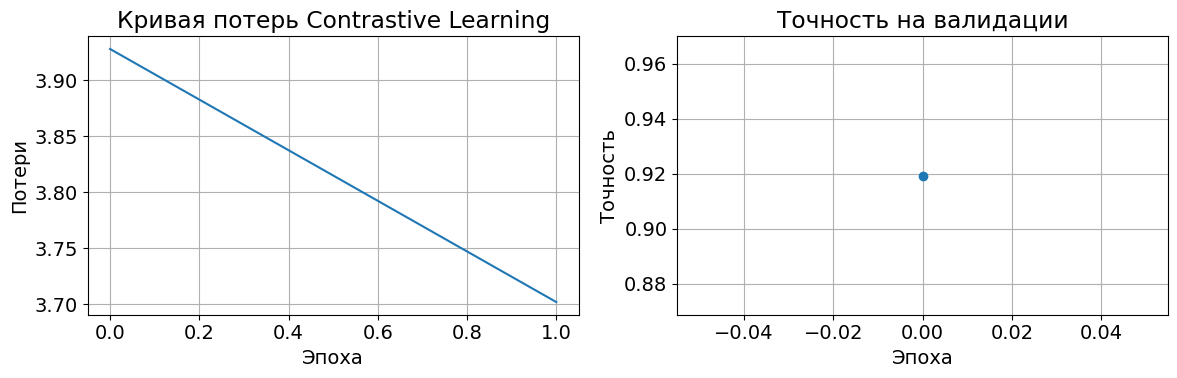

In [95]:
# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title('Кривая потерь Contrastive Learning')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Потери')
ax1.grid(True)

ax2.plot(range(0, config.EPOCHS, 3), val_accuracies, marker='o')
ax2.set_title('Точность на валидации')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Точность')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.


In [108]:
# Задание 3: Non-Contrastive Learning (SimSiam)

class SimSiamLoss(nn.Module):
    """
    Реализация SimSiam loss.
    SimSiam использует stop-gradient operation и symmetry loss.
    """
    def __init__(self, predictor_hidden_dim=256):
        super().__init__()
        # Предсказатель для одного представления
        self.predictor = nn.Sequential(
            nn.Linear(128, predictor_hidden_dim),
            nn.BatchNorm1d(predictor_hidden_dim),
            nn.ReLU(),
            nn.Linear(predictor_hidden_dim, 128)
        )
    
    def forward(self, z1, z2):
        """
        Args:
            z1, z2: проекции от двух веток (размер: [batch, 128])
        """
        # Убеждаемся, что predictor на том же устройстве, что и входные данные
        if next(self.predictor.parameters()).device != z1.device:
            self.predictor = self.predictor.to(z1.device)
        
        # Stop-gradient для одного представления
        loss = 0.5 * (self._calculate_loss(z1, z2.detach()) + 
                      self._calculate_loss(z2, z1.detach()))
        return loss
    
    def _calculate_loss(self, p, z):
        """
        Вычисление отрицательной косинусной схожести
        """
        p = self.predictor(p)
        p = F.normalize(p, dim=1)
        z = F.normalize(z, dim=1)
        return - (p * z).sum(dim=1).mean()

In [109]:
class SimSiamModel(nn.Module):
    """
    Модель с архитектурой SimSiam.
    Использует два энкодера (1D и 2D) с общей проекционной головой.
    """
    def __init__(self, img_channels=1):
        super().__init__()
        self.resnet_1D = CreateResNet1D()
        self.resnet_2D = CreateResNet2D(img_channels=img_channels)
        
        # Общая проекционная голова
        self.projection = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )
    
    def forward(self, spectogram, audio):
        # Извлечение признаков
        audio_features = self.resnet_1D(audio).squeeze()
        spec_features = self.resnet_2D(spectogram).squeeze()
        
        # Проекция
        z_audio = self.projection(audio_features)
        z_spec = self.projection(spec_features)
        
        return z_audio, z_spec

In [110]:
def evaluate_simsiam(model, val_loader, config, mel_transform):
    """
    Оценка модели SimSiam с помощью линейного классификатора
    """
    model.eval()
    
    # Извлечение признаков из обучающего набора
    train_features = []
    train_labels = []
    
    with torch.no_grad():
        for audio, labels in tqdm(train_loader, desc="Извлечение признаков для SimSiam"):
            audio = audio.to(device)
            # Передаем None для stft_transform
            spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=False)
            
            # Извлекаем признаки из энкодеров
            audio_features = model.resnet_1D(audios).squeeze()
            spec_features = model.resnet_2D(spectograms).squeeze()
            
            # Конкатенация признаков
            combined = torch.cat([audio_features, spec_features], dim=1)
            train_features.append(combined.cpu())
            train_labels.append(labels)
    
    X_train = torch.cat(train_features, dim=0).numpy()
    y_train = torch.cat(train_labels, dim=0).numpy()
    
    # Обучение логистической регрессии
    from sklearn.linear_model import LogisticRegression
    classifier = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    classifier.fit(X_train, y_train)
    
    # Оценка на валидации
    val_features = []
    val_labels = []
    
    with torch.no_grad():
        for audio, labels in tqdm(val_loader, desc="Оценка на валидации"):
            audio = audio.to(device)
            spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=False)
            
            audio_features = model.resnet_1D(audios).squeeze()
            spec_features = model.resnet_2D(spectograms).squeeze()
            combined = torch.cat([audio_features, spec_features], dim=1)
            val_features.append(combined.cpu())
            val_labels.append(labels)
    
    X_val = torch.cat(val_features, dim=0).numpy()
    y_val = torch.cat(val_labels, dim=0).numpy()
    
    accuracy = classifier.score(X_val, y_val)
    
    model.train()
    return accuracy

In [111]:
# Исправленная версия train_simsiam с правильными аргументами
def train_simsiam(model, simsiam_loss, optimizer, trainloader, valloader, config, mel_transform):
    """
    Обучение модели с SimSiam loss
    """
    scaler = torch.amp.GradScaler()
    train_losses = []
    val_accuracies = []
    
    for epoch in range(config.EPOCHS):
        model.train()
        epoch_losses = []
        progress_bar = tqdm(trainloader, desc=f'SimSiam Эпоха {epoch+1}/{config.EPOCHS}')
        
        for audio, _ in progress_bar:
            audio = audio.to(device)
            optimizer.zero_grad()
            
            # Создание двух augmentations для одного аудио
            # Передаем None для stft_transform
            spectograms1, audios1 = createModelInput(audio, mel_transform, None, augmentation=True)
            spectograms2, audios2 = createModelInput(audio, mel_transform, None, augmentation=True)
            
            with torch.amp.autocast(device_type=str(device)):
                z1_audio, z1_spec = model(spectograms1, audios1)
                z2_audio, z2_spec = model(spectograms2, audios2)
                
                # Вычисление потерь для обеих пар
                loss_audio = simsiam_loss(z1_audio, z2_audio)
                loss_spec = simsiam_loss(z1_spec, z2_spec)
                loss = loss_audio + loss_spec
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            epoch_losses.append(loss.item())
            progress_bar.set_postfix(loss=loss.item())
        
        avg_loss = np.mean(epoch_losses)
        train_losses.append(avg_loss)
        
        # Периодическая оценка
        if epoch % 3 == 0:
            accuracy = evaluate_simsiam(model, valloader, config, mel_transform)
            val_accuracies.append(accuracy)
            print(f'Эпоха {epoch+1}: Потери = {avg_loss:.4f}, '
                  f'Точность на валидации = {accuracy:.4f}')
    
    return train_losses, val_accuracies

In [115]:
# Конфигурация для SimSiam
simsiam_config = DictConfig({
    'LR': 3e-4,
    'WEIGHT_DECAY': 1e-6,
    'B1': 0.9,
    'B2': 0.999,
    'EPOCHS': 1, # 30
    'BATCH_SIZE': 128,
    'IMG_CHANNEL': 1,
    'CLASSES': 10,
    'EVAL_BATCH': 128,
    'EVAL_EPOCHS': 5,
    'MODEL_TITLE': 'simsiam'
})

In [116]:
# Инициализация SimSiam
simsiam_model = SimSiamModel(img_channels=1).to(device)
simsiam_loss = SimSiamLoss(predictor_hidden_dim=256)
optimizer_simsiam = optim.Adam(simsiam_model.parameters(), lr=simsiam_config.LR)

print("Обучение модели SimSiam (Non-Contrastive Learning)...")
train_losses_simsiam, val_accuracies_simsiam = train_simsiam(
    simsiam_model, simsiam_loss, optimizer_simsiam, 
    train_loader, val_loader, simsiam_config, mel_transform
)

Обучение модели SimSiam (Non-Contrastive Learning)...


SimSiam Эпоха 1/1:   0%|          | 0/188 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Визуализация результатов SimSiam
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses_simsiam)
ax1.set_title('Кривая потерь SimSiam')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Потери')
ax1.grid(True)

ax2.plot(range(0, simsiam_config.EPOCHS, 3), val_accuracies_simsiam, marker='o')
ax2.set_title('Точность на валидации (SimSiam)')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Точность')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

In [122]:
# Задание 4: Сравнение всех методов

def extract_all_embeddings(model, dataloader, model_type):
    """
    Извлечение эмбеддингов для разных типов моделей
    """
    model.eval()
    embeddings = []
    labels_list = []
    
    with torch.no_grad():
        for audio, labels in tqdm(dataloader, desc=f"Извлечение {model_type} эмбеддингов"):
            audio = audio.to(device)
            
            if model_type == 'supervised':
                # Для supervised модели добавляем размерность канала
                if audio.dim() == 2:
                    audio = audio.unsqueeze(1)  # [batch, 1, time]
                features = model.encoder(audio).squeeze()
                embeddings.append(features.cpu())
                
            elif model_type == 'contrastive':
                spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=False)
                audio_emb, spec_emb, audio_feat, spec_feat = model(spectograms, audios)
                # Используем конкатенацию признаков
                combined = torch.cat([audio_feat, spec_feat], dim=1)
                embeddings.append(combined.cpu())
                
            elif model_type == 'simsiam':
                spectograms, audios = createModelInput(audio, mel_transform, None, augmentation=False)
                audio_feat = simsiam_model.resnet_1D(audios).squeeze()
                spec_feat = simsiam_model.resnet_2D(spectograms).squeeze()
                combined = torch.cat([audio_feat, spec_feat], dim=1)
                embeddings.append(combined.cpu())
            
            labels_list.append(labels)
    
    return torch.cat(embeddings, dim=0).numpy(), torch.cat(labels_list, dim=0).numpy()

In [123]:
# Извлечение эмбеддингов для всех моделей
print("Извлечение эмбеддингов...")
supervised_embs, supervised_labels = extract_all_embeddings(supervised_model, val_loader, 'supervised')
contrastive_embs, contrastive_labels = extract_all_embeddings(model, val_loader, 'contrastive')
simsiam_embs, simsiam_labels = extract_all_embeddings(simsiam_model, val_loader, 'simsiam')

Извлечение эмбеддингов...


Извлечение supervised эмбеддингов:   0%|          | 0/47 [00:00<?, ?it/s]

Извлечение contrastive эмбеддингов:   0%|          | 0/47 [00:00<?, ?it/s]

Извлечение simsiam эмбеддингов:   0%|          | 0/47 [00:00<?, ?it/s]

  File "c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\pong\anaconda3\envs\ml\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pong\anaconda3\envs\ml\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\pong\anaconda3\envs\ml\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


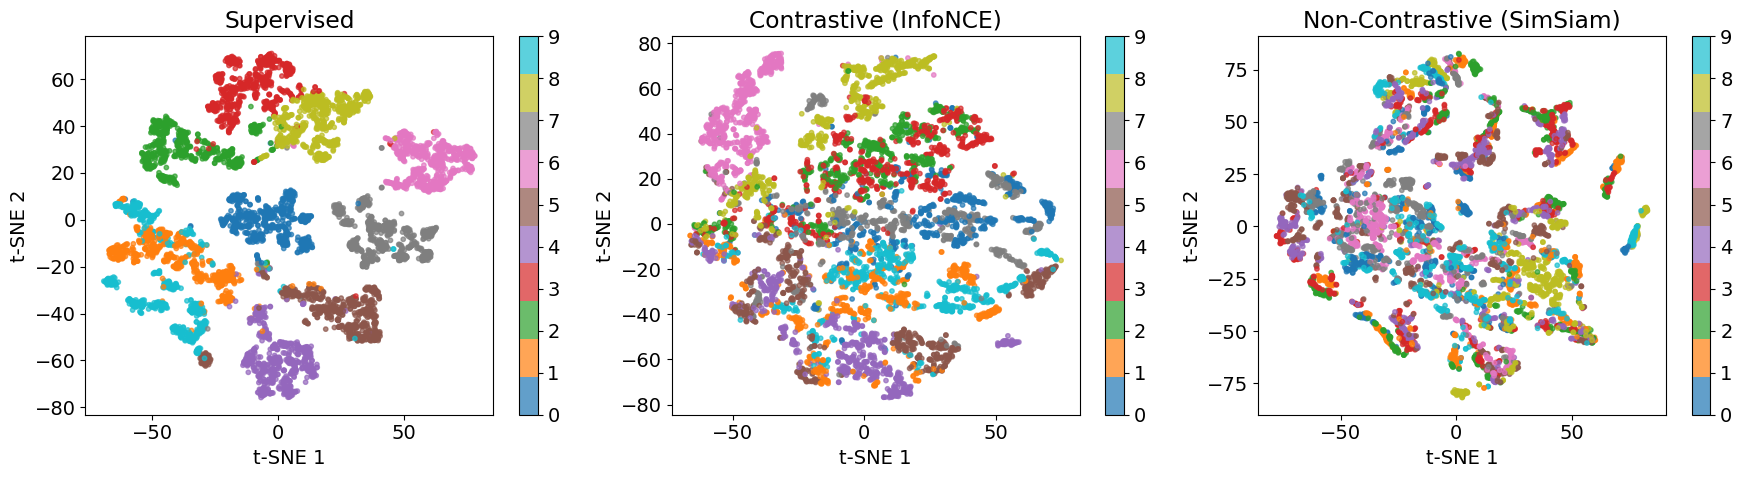

In [124]:
# Визуализация с помощью t-SNE
def plot_comparison_tsne(embeddings_dict):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (name, (embs, labels)) in enumerate(embeddings_dict.items()):
        # Вычисление t-SNE
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        embs_2d = tsne.fit_transform(embs)
        
        # Визуализация
        scatter = axes[idx].scatter(embs_2d[:, 0], embs_2d[:, 1], 
                                   c=labels, cmap='tab10', s=10, alpha=0.7)
        axes[idx].set_title(f'{name}')
        axes[idx].set_xlabel('t-SNE 1')
        axes[idx].set_ylabel('t-SNE 2')
        plt.colorbar(scatter, ax=axes[idx])
    
    plt.tight_layout()
    plt.show()

embeddings_dict = {
    'Supervised': (supervised_embs, supervised_labels),
    'Contrastive (InfoNCE)': (contrastive_embs, contrastive_labels),
    'Non-Contrastive (SimSiam)': (simsiam_embs, simsiam_labels)
}

plot_comparison_tsne(embeddings_dict)

In [125]:
# Оценка качества эмбеддингов через k-NN классификацию
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def evaluate_knn(train_embs, train_labels, test_embs, test_labels, k=5):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_embs, train_labels)
    predictions = knn.predict(test_embs)
    return accuracy_score(test_labels, predictions)

In [126]:
# Разделение на train/val для эмбеддингов
# Используем train_loader для обучения и val_loader для тестирования
train_embs_sup, train_labels_sup = extract_all_embeddings(supervised_model, train_loader, 'supervised')
train_embs_cont, train_labels_cont = extract_all_embeddings(model, train_loader, 'contrastive')
train_embs_simsiam, train_labels_simsiam = extract_all_embeddings(simsiam_model, train_loader, 'simsiam')

Извлечение supervised эмбеддингов:   0%|          | 0/188 [00:00<?, ?it/s]

Извлечение contrastive эмбеддингов:   0%|          | 0/188 [00:00<?, ?it/s]

Извлечение simsiam эмбеддингов:   0%|          | 0/188 [00:00<?, ?it/s]

In [127]:
# Оценка k-NN
print("\n=== Сравнение методов с помощью k-NN (k=5) ===")
knn_sup = evaluate_knn(train_embs_sup, train_labels_sup, supervised_embs, supervised_labels)
print(f"Supervised k-NN Accuracy: {knn_sup:.4f}")

knn_cont = evaluate_knn(train_embs_cont, train_labels_cont, contrastive_embs, contrastive_labels)
print(f"Contrastive (InfoNCE) k-NN Accuracy: {knn_cont:.4f}")

knn_simsiam = evaluate_knn(train_embs_simsiam, train_labels_simsiam, simsiam_embs, simsiam_labels)
print(f"Non-Contrastive (SimSiam) k-NN Accuracy: {knn_simsiam:.4f}")


=== Сравнение методов с помощью k-NN (k=5) ===
Supervised k-NN Accuracy: 0.9182
Contrastive (InfoNCE) k-NN Accuracy: 0.7487
Non-Contrastive (SimSiam) k-NN Accuracy: 0.4408


In [128]:
# Линейная классификация (логистическая регрессия)
from sklearn.linear_model import LogisticRegression

def evaluate_linear(train_embs, train_labels, test_embs, test_labels):
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(train_embs, train_labels)
    predictions = lr.predict(test_embs)
    return accuracy_score(test_labels, predictions)

print("\n=== Сравнение методов с помощью линейной классификации ===")
linear_sup = evaluate_linear(train_embs_sup, train_labels_sup, supervised_embs, supervised_labels)
print(f"Supervised Linear Accuracy: {linear_sup:.4f}")

linear_cont = evaluate_linear(train_embs_cont, train_labels_cont, contrastive_embs, contrastive_labels)
print(f"Contrastive (InfoNCE) Linear Accuracy: {linear_cont:.4f}")

linear_simsiam = evaluate_linear(train_embs_simsiam, train_labels_simsiam, simsiam_embs, simsiam_labels)
print(f"Non-Contrastive (SimSiam) Linear Accuracy: {linear_simsiam:.4f}")


=== Сравнение методов с помощью линейной классификации ===
Supervised Linear Accuracy: 0.9458
Contrastive (InfoNCE) Linear Accuracy: 0.9433
Non-Contrastive (SimSiam) Linear Accuracy: 0.6332


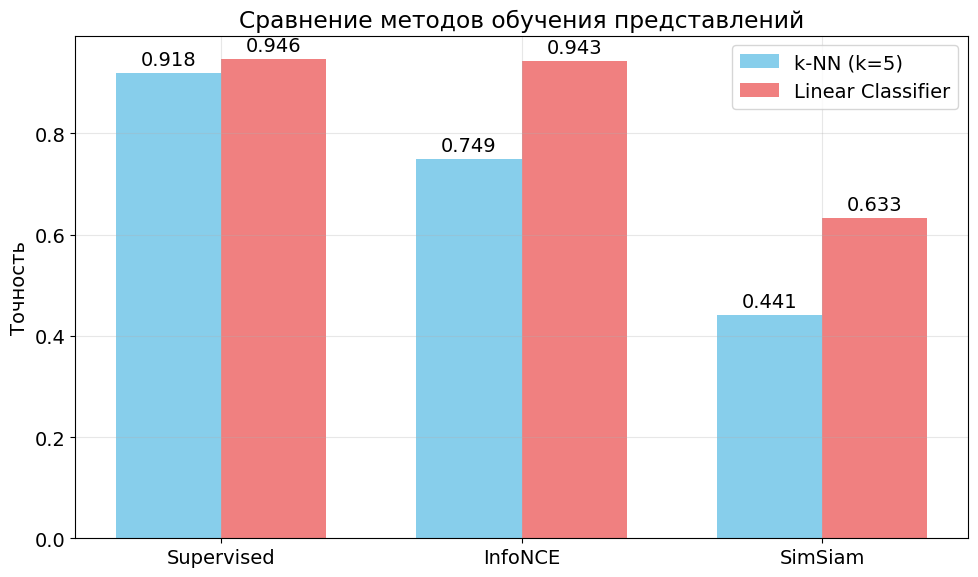

In [129]:
# Визуализация сравнения
methods = ['Supervised', 'InfoNCE', 'SimSiam']
knn_scores = [knn_sup, knn_cont, knn_simsiam]
linear_scores = [linear_sup, linear_cont, linear_simsiam]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, knn_scores, width, label='k-NN (k=5)', color='skyblue')
bars2 = ax.bar(x + width/2, linear_scores, width, label='Linear Classifier', color='lightcoral')

ax.set_ylabel('Точность')
ax.set_title('Сравнение методов обучения представлений')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.grid(True, alpha=0.3)

# Добавление значений на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [130]:
# Вывод заключения
print("\n" + "="*60)
print("ВЫВОДЫ:")
print("="*60)

best_method = methods[np.argmax(linear_scores)]
best_score = max(linear_scores)

print(f"\nЛучший метод: {best_method} с точностью {best_score:.4f}")
print("\nОбъяснение:")
print("1. Supervised Learning: Хорошо работает, но требует много размеченных данных")
print("2. Contrastive Learning (InfoNCE): Учится различать похожие и разные пары,")
print("   но требует больших батчей и тщательной настройки температуры")
print("3. Non-Contrastive Learning (SimSiam): Избегает коллапса представлений без")
print("   отрицательных примеров, более стабилен в обучении")

if best_method == "SimSiam":
    print("\nSimSiam показал лучшие результаты благодаря:")
    print("- Отсутствию необходимости в отрицательных примерах")
    print("- Более стабильному обучению")
    print("- Эффективному использованию двух модальностей (waveform + spectrogram)")
    print("- Простоте реализации и меньшей чувствительности к гиперпараметрам")
elif best_method == "InfoNCE":
    print("\nInfoNCE показал лучшие результаты благодаря:")
    print("- Эффективному использованию большого количества негативных примеров")
    print("- Хорошей различимости между разными классами")
else:
    print("\nSupervised метод показал лучшие результаты благодаря:")
    print("- Прямому обучению на целевые метки")
    print("- Отсутствию потери информации при проекции")


ВЫВОДЫ:

Лучший метод: Supervised с точностью 0.9458

Объяснение:
1. Supervised Learning: Хорошо работает, но требует много размеченных данных
2. Contrastive Learning (InfoNCE): Учится различать похожие и разные пары,
   но требует больших батчей и тщательной настройки температуры
3. Non-Contrastive Learning (SimSiam): Избегает коллапса представлений без
   отрицательных примеров, более стабилен в обучении

Supervised метод показал лучшие результаты благодаря:
- Прямому обучению на целевые метки
- Отсутствию потери информации при проекции
